# Exp3 – Data Preparation Walkthrough

This notebook demonstrates the complete data pipeline for **Experiment 3: DNase-based Multimodal Extension**.  
We show how raw DNase-seq narrowPeak files are converted into the per-TF HDF5 datasets used for fine-tuning.

**TF used for demonstration:** CTCF  
**Cell lines for training:** K562, HepG2, Lung  
**Cell line for testing:** GM12878 (held-out)

## Pipeline overview

```
DNase narrowPeak  ──►  00_prepare_dnase_bins.sh
                          │  Summit-centred 1000 bp bins
                          │  Blacklist removal, chr split
                          ▼
                       01_create_datasets.sh
                          │  HDF5 per (cell_line × TF)
                          │  sequence + DNase signal + label
                          ▼
                       02_merge_datasets.sh
                          │  Merge K562/HepG2/Lung → train/val
                          │  GM12878 stays as test split
                          ▼
                  CTCF_train_merged.h5
                  CTCF_val_merged.h5
                  CTCF_test_GM12878.h5
```

## 0. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['font.family']    = 'sans-serif'
plt.rcParams['font.sans-serif']= ['Arial']
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

# Paths
DATASET_DIR = (
    '/dataset/zjn_zjj/DLM/10_21_previous_work/'
    'Data_associated_with_Graduation/DNase_implement/'
    'Data/dataset/imbalanced'
)
CTCF_TRAIN = f'{DATASET_DIR}/train/CTCF_train_merged.h5'
CTCF_VAL   = f'{DATASET_DIR}/val/CTCF_val_merged.h5'
CTCF_TEST  = f'{DATASET_DIR}/test/CTCF_test_GM12878.h5'

print('Dataset directory:', DATASET_DIR)
for p in [CTCF_TRAIN, CTCF_VAL, CTCF_TEST]:
    tag = '✓' if os.path.isfile(p) else '✗'
    print(f'  {tag}  {os.path.basename(p)}')

Dataset directory: /dataset/zjn_zjj/DLM/10_21_previous_work/Data_associated_with_Graduation/DNase_implement/Data/dataset/imbalanced
  ✓  CTCF_train_merged.h5
  ✓  CTCF_val_merged.h5
  ✓  CTCF_test_GM12878.h5


---
## Step 1 – Generate DNase-centred Bins

`scripts/00_prepare_dnase_bins.sh` wraps the following logic for every cell line:

```bash
# Example for CTCF / K562
bash scripts/00_prepare_dnase_bins.sh

# Internally it runs:
#   bedtools slop  -i dnase.narrowPeak  -b 500  →  1000 bp windows
#   bedtools intersect  -v  -a windows  -b blacklist.bed  →  remove artefacts
#   awk '$1 == "chrNN"'  →  separate train / test chromosomes
#
# Train chromosomes : chr1, chr11, chr13, chr19
# Test  chromosome  : chr12
```

The output is a set of BED files, one per (cell_line × chrom_split).

### Chromosome split rationale
| Split | Chromosomes | Purpose |
|-------|-------------|----------|
| train | chr1, 11, 13, 19 | K562 + HepG2 + Lung merged |
| val   | chr1, 11, 13, 19 | Same chromosomes, set aside during merge |
| test  | chr12 | GM12878 **only** – never seen during training |

---
## Step 2 – Create Per-TF HDF5 Datasets

`scripts/01_create_datasets.sh` runs `python -m exp3_dnase.preprocess.create_peak_datasets` in two stages:

```bash
# Stage A: pre-compute DNase signals into .npy cache files (one per BED row)
DATA_ROOT=/path/to/Data bash scripts/01_create_datasets.sh

# Stage B: combine BED + bigWig signals + TF ChIP-seq into HDF5
# HDF5 schema:
#   chroms        (N,)   bytes   – chromosome name
#   starts        (N,)   int32   – window start
#   ends          (N,)   int32   – window end
#   sequences     (N,)   bytes   – 1000 nt DNA sequence (ACGT)
#   dnase_signals (N, L) float32 – per-base DNase-seq signal
#   labels        (N,)   int8    – 1 if ≥50% of window overlaps TF peak
```

**Positive label criterion:** a 1000 bp bin is labelled positive if it overlaps ≥ 50% of a TF ChIP-seq peak's length.

---
## Step 3 – Merge Cross-Cell Datasets

`scripts/02_merge_datasets.sh` calls `python -m exp3_dnase.preprocess.merge_cross_cell_datasets --mode all`:

```bash
bash scripts/02_merge_datasets.sh
```

For each TF it concatenates the K562 / HepG2 / Lung splits into a single `*_train_merged.h5` and `*_val_merged.h5`, while the GM12878 HDF5 becomes `*_test_GM12878.h5` unchanged.

---
## Inspect the CTCF datasets

The three merged HDF5 files are already on disk. Let us inspect them without running the preprocessing pipeline.

In [2]:
def describe_h5(path, split_name):
    with h5py.File(path, 'r') as f:
        labels = f['labels'][:]
        seqs   = f['sequences'][:]
        sig    = f['dnase_signals'][:]
        starts = f['starts'][:]

        n_total = len(labels)
        n_pos   = int(labels.sum())
        imbalance = n_total / max(n_pos, 1)

        print(f'── {split_name} ({os.path.basename(path)}) ──')
        print(f'  samples      : {n_total:>8,}')
        print(f'  positives    : {n_pos:>8,}  ({n_pos/n_total*100:.1f}%)')
        print(f'  neg/pos ratio: {imbalance:.1f}:1')
        print(f'  sequence len : {len(seqs[0].decode())} nt')
        print(f'  dnase shape  : {sig.shape}')
        print(f'  signal range : [{sig.min():.4f}, {sig.max():.4f}]')
        print()
    return labels, sig

train_labels, train_sig = describe_h5(CTCF_TRAIN, 'train (K562+HepG2+Lung)')
val_labels,   val_sig   = describe_h5(CTCF_VAL,   'val   (K562+HepG2+Lung)')
test_labels,  test_sig  = describe_h5(CTCF_TEST,  'test  (GM12878)')

── train (K562+HepG2+Lung) (CTCF_train_merged.h5) ──
  samples      :   86,157
  positives    :   26,295  (30.5%)
  neg/pos ratio: 3.3:1
  sequence len : 1000 nt
  dnase shape  : (86157, 1000)
  signal range : [0.0000, 25.6944]

── val   (K562+HepG2+Lung) (CTCF_val_merged.h5) ──
  samples      :    9,572
  positives    :    2,921  (30.5%)
  neg/pos ratio: 3.3:1
  sequence len : 1000 nt
  dnase shape  : (9572, 1000)
  signal range : [0.0000, 24.9813]

── test  (GM12878) (CTCF_test_GM12878.h5) ──
  samples      :    2,613
  positives    :      756  (28.9%)
  neg/pos ratio: 3.5:1
  sequence len : 1000 nt
  dnase shape  : (2613, 1000)
  signal range : [0.0000, 23.5995]



### Label distribution

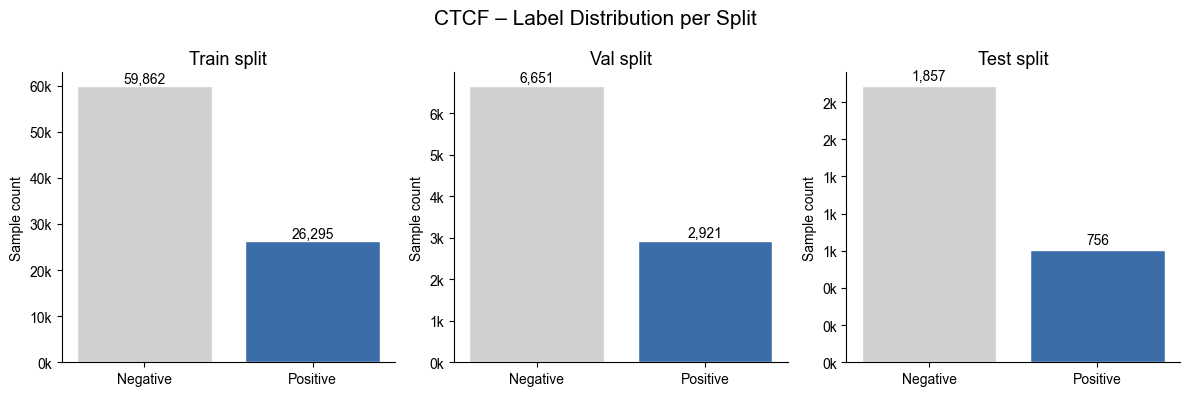

In [3]:
splits = [
    ('Train', train_labels),
    ('Val',   val_labels),
    ('Test',  test_labels),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colors_pos = '#3B6EA8'
colors_neg = '#D0D0D0'

for ax, (name, lbl) in zip(axes, splits):
    n_pos = int(lbl.sum())
    n_neg = len(lbl) - n_pos
    ax.bar(['Negative', 'Positive'], [n_neg, n_pos],
           color=[colors_neg, colors_pos], edgecolor='white')
    ax.set_title(f'{name} split', fontsize=13)
    ax.set_ylabel('Sample count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
    for bar, val in zip(ax.patches, [n_neg, n_pos]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                f'{val:,}', ha='center', va='bottom', fontsize=10)

fig.suptitle('CTCF – Label Distribution per Split', fontsize=15)
fig.tight_layout()
plt.show()

### DNase signal examples

Each row in `dnase_signals` is a 1000-element vector giving the per-base DNase-seq read-depth in the 1000 bp window.  
Positive samples (TF-bound) typically show an accessible chromatin peak at the binding site.

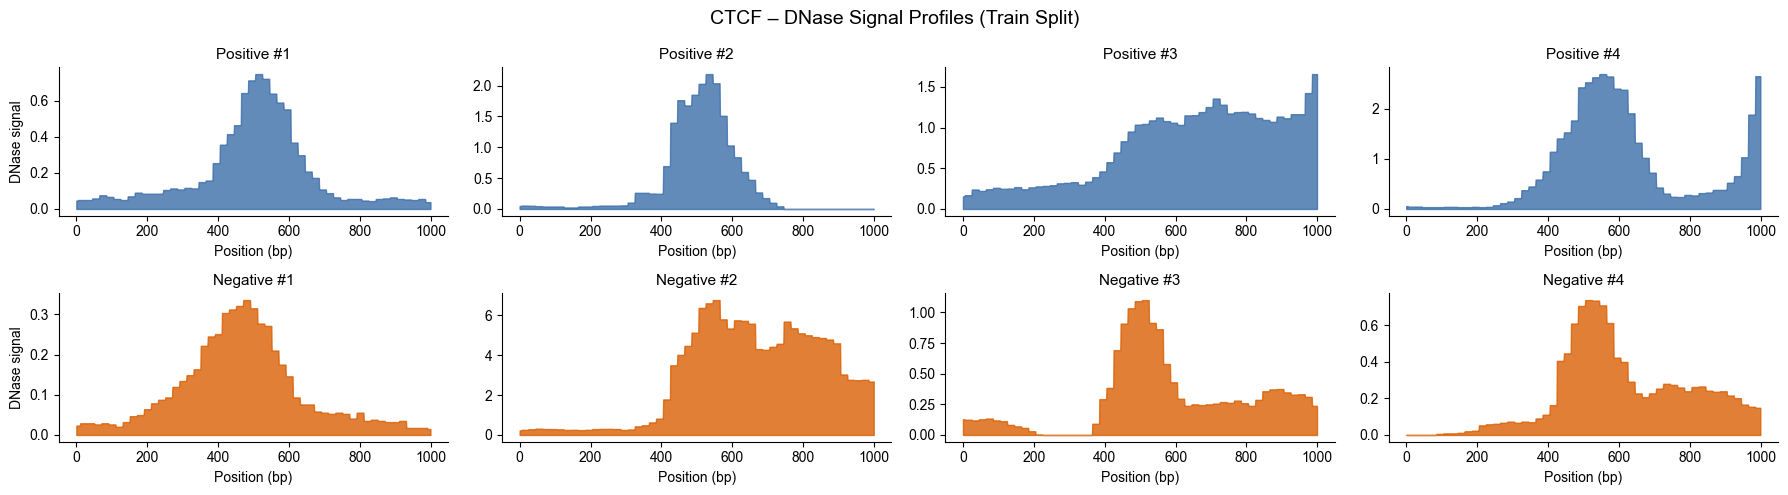

In [4]:
with h5py.File(CTCF_TRAIN, 'r') as f:
    labels_arr = f['labels'][:]
    signals    = f['dnase_signals'][:]

pos_idx = np.where(labels_arr == 1)[0]
neg_idx = np.where(labels_arr == 0)[0]
rng = np.random.default_rng(42)
sample_pos = rng.choice(pos_idx, size=4, replace=False)
sample_neg = rng.choice(neg_idx, size=4, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(18, 5), sharey=False)
x = np.arange(1000)

for col, idx in enumerate(sample_pos):
    ax = axes[0, col]
    ax.fill_between(x, signals[idx], alpha=0.8, color='#3B6EA8')
    ax.set_title(f'Positive #{col+1}', fontsize=11)
    ax.set_xlabel('Position (bp)')
    if col == 0:
        ax.set_ylabel('DNase signal')

for col, idx in enumerate(sample_neg):
    ax = axes[1, col]
    ax.fill_between(x, signals[idx], alpha=0.8, color='#D95F02')
    ax.set_title(f'Negative #{col+1}', fontsize=11)
    ax.set_xlabel('Position (bp)')
    if col == 0:
        ax.set_ylabel('DNase signal')

fig.suptitle('CTCF – DNase Signal Profiles (Train Split)', fontsize=14)
fig.tight_layout()
plt.show()

### Signal intensity by label

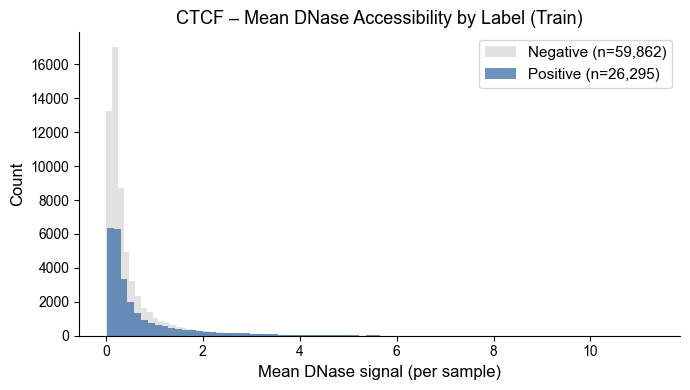

Positive mean signal: 0.6838 ± 0.9343
Negative mean signal: 0.4705 ± 0.6377


In [5]:
pos_mean_signal = train_sig[train_labels == 1].mean(axis=1)
neg_mean_signal = train_sig[train_labels == 0].mean(axis=1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(neg_mean_signal, bins=80, alpha=0.6, color='#D0D0D0',
        label=f'Negative (n={len(neg_mean_signal):,})')
ax.hist(pos_mean_signal, bins=80, alpha=0.75, color='#3B6EA8',
        label=f'Positive (n={len(pos_mean_signal):,})')
ax.set_xlabel('Mean DNase signal (per sample)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('CTCF – Mean DNase Accessibility by Label (Train)', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f'Positive mean signal: {pos_mean_signal.mean():.4f} ± {pos_mean_signal.std():.4f}')
print(f'Negative mean signal: {neg_mean_signal.mean():.4f} ± {neg_mean_signal.std():.4f}')

### Sequence inspection

In [6]:
with h5py.File(CTCF_TRAIN, 'r') as f:
    sequences = [s.decode('ascii') for s in f['sequences'][:5]]
    labs      = f['labels'][:5]
    chroms    = [c.decode('utf-8') for c in f['chroms'][:5]]
    starts    = f['starts'][:5]
    ends      = f['ends'][:5]

print('First 5 records from CTCF_train_merged.h5:\n')
print(f'{"chrom":<8} {"start":<10} {"end":<10} {"label":<7} {"sequence (first 30 nt)"}')
print('-' * 65)
for ch, st, en, lb, sq in zip(chroms, starts, ends, labs, sequences):
    print(f'{ch:<8} {st:<10} {en:<10} {lb:<7} {sq[:30]}...')

First 5 records from CTCF_train_merged.h5:

chrom    start      end        label   sequence (first 30 nt)
-----------------------------------------------------------------
chr1     241848323  241849323  0       AAGGGGAGGAGGAGAGTCCCTTCTCGGAAG...
chr19    16943537   16944537   0       GATTACAGGTGTGAGCCACCACACCCAGCC...
chr11    86069315   86070315   0       GACTCTCCCTGCCAACAGGTCGCCTGAGGC...
chr1     204859575  204860575  0       ATGTCTGAGACAACAACTGGGTCTTGGGTC...
chr19    5691935    5692935    0       GTGGCTCCACTGCCAGGTCCGGGCGCGCTC...


---
## BPE tokenization + DNase alignment

When fine-tuning BPE-based models (DNABERT-2, GROVER), each DNA sequence is tokenised using the model's BPE vocabulary.  
Because BPE tokens span variable numbers of base-pairs, DNase signals are aligned via **offset mapping**: for each token `(start, end)` from the tokeniser, we take the max signal over `signal[start:end]`.

In [7]:
from transformers import AutoTokenizer

GROVER_PATH = '/dataset/zjn_zjj/DLM/GFM_model_files/GROVER'
tokenizer = AutoTokenizer.from_pretrained(GROVER_PATH, trust_remote_code=True)
tokenizer.model_max_length = 1002

with h5py.File(CTCF_TRAIN, 'r') as f:
    seq    = f['sequences'][0].decode('ascii')
    signal = f['dnase_signals'][0]

enc = tokenizer(
    seq,
    max_length=tokenizer.model_max_length,
    truncation=True,
    return_offsets_mapping=True,
)
offsets = enc['offset_mapping']

print(f'Sequence length  : {len(seq)} nt')
print(f'Number of tokens : {len(enc["input_ids"])}')
print(f'\nFirst 8 tokens (id, chars, dnase_max):')
print(f'{"token":<6} {"id":<8} {"chars":<20} {"dnase_max"}')
print('-' * 50)
for i, (tok_id, (s, e)) in enumerate(zip(enc['input_ids'][:8], offsets[:8])):
    chars = seq[s:e] if e > s else '[special]'
    sig_val = float(signal[s:e].max()) if e > s and e <= len(signal) else 0.0
    token_str = tokenizer.convert_ids_to_tokens([tok_id])[0]
    print(f'{i:<6} {tok_id:<8} {repr(chars):<20} {sig_val:.4f}')

/home/zhangjiajing/miniforge3/envs/glm_hf/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sequence length  : 1000 nt
Number of tokens : 258

First 8 tokens (id, chars, dnase_max):
token  id       chars                dnase_max
--------------------------------------------------
0      2        '[special]'          0.0000
1      506      'AAGGGG'             0.3230
2      327      'AGGAGG'             0.3230
3      65       'AGAG'               0.3230
4      52       'TCCC'               0.3230
5      132      'TTCTC'              0.2651
6      16       'GG'                 0.2651
7      50       'AAGG'               0.2651


---
## Summary

| File | Contents |
|------|----------|
| `CTCF_train_merged.h5` | K562 + HepG2 + Lung; chr1/11/13/19 |
| `CTCF_val_merged.h5`   | K562 + HepG2 + Lung; chr1/11/13/19 (held-out rows) |
| `CTCF_test_GM12878.h5` | GM12878 only; chr12 – **never seen during training** |

Each HDF5 stores: `chroms`, `starts`, `ends`, `sequences`, `dnase_signals`, `labels`.

Proceed to **`02_finetune_and_visualize.ipynb`** for model fine-tuning and AUPRC comparison.